# Tutorial 15: Long Short-Term Memory (LSTM)

### Objectives:
1. Understand the architecture of LSTM
2. Implement the LSTM
3. Compare it with Simple RNN
4. Build an LSTM model for sentiment analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN

# Load the IMDB dataset for sentiment analysis
max_features = 10000
maxlen = 500

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), 'train sequences')
print(len(input_test), 'test sequences')

print('Pad sequences (samples x time)')
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape: (25000, 500)
input_test shape: (25000, 500)


### Task 1: Compare LSTM with Simple RNN
LSTMs are designed to avoid the vanishing gradient problem found in Simple RNNs, allowing them to learn long-term dependencies.

In [ ]:
# Simple RNN Model for Comparison
rnn_model = Sequential([
    Embedding(max_features, 32),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
print("Training Simple RNN...")
rnn_history = rnn_model.fit(input_train, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=1)

Training Simple RNN...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 177ms/step - acc: 0.6755 - loss: 0.5917 - val_acc: 0.8206 - val_loss: 0.4269
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - acc: 0.8241 - loss: 0.4009 - val_acc: 0.8190 - val_loss: 0.4090
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - acc: 0.8616 - loss: 0.3307 - val_acc: 0.8214 - val_loss: 0.4005
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 174ms/step - acc: 0.8829 - loss: 0.2876 - val_acc: 0.8114 - val_loss: 0.4124
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 172ms/step - acc: 0.9135 - loss: 0.2225 - val_acc: 0.8188 - val_loss: 0.4303


In [ ]:
# LSTM Model for Sentiment Analysis
lstm_model = Sequential([
    Embedding(max_features, 32),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
print("Training LSTM...")
lstm_history = lstm_model.fit(input_train, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=1)

Training LSTM...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 311ms/step - acc: 0.6514 - loss: 0.6100 - val_acc: 0.7982 - val_loss: 0.4636
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 298ms/step - acc: 0.8259 - loss: 0.4018 - val_acc: 0.7168 - val_loss: 0.6283
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 303ms/step - acc: 0.8691 - loss: 0.3251 - val_acc: 0.8752 - val_loss: 0.3133
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 304ms/step - acc: 0.8737 - loss: 0.3108 - val_acc: 0.8734 - val_loss: 0.3050
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 303ms/step - acc: 0.8926 - loss: 0.2707 - val_acc: 0.8634 - val_loss: 0.3411


### Visualizing the Results
Comparing the accuracy and loss between the Simple RNN and the LSTM.

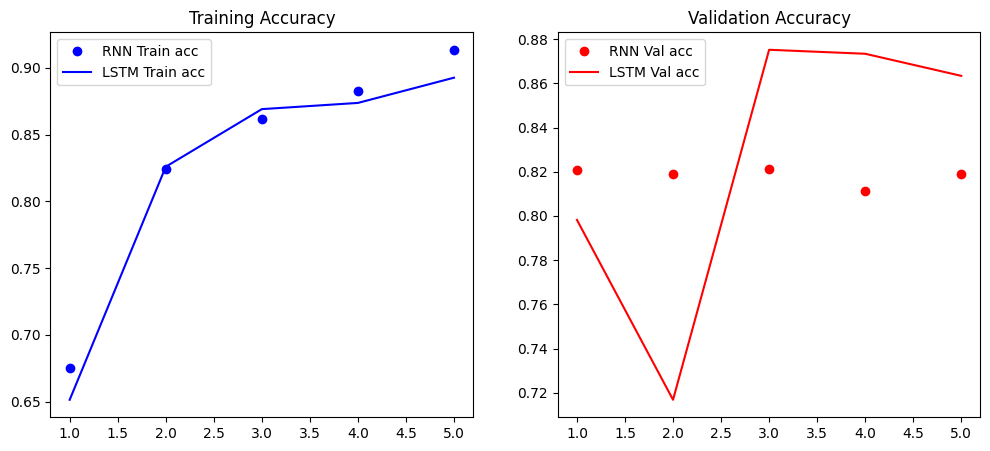

In [ ]:
def plot_history(rnn_hist, lstm_hist):
    acc_rnn = rnn_hist.history['acc']
    val_acc_rnn = rnn_hist.history['val_acc']
    acc_lstm = lstm_hist.history['acc']
    val_acc_lstm = lstm_hist.history['val_acc']
    epochs = range(1, len(acc_rnn) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc_rnn, 'bo', label='RNN Train acc')
    plt.plot(epochs, acc_lstm, 'b', label='LSTM Train acc')
    plt.title('Training Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_acc_rnn, 'ro', label='RNN Val acc')
    plt.plot(epochs, val_acc_lstm, 'r', label='LSTM Val acc')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.show()

plot_history(rnn_history, lstm_history)